<a href="https://colab.research.google.com/github/AndreaGS99/Amigo-Secreto/blob/main/FallasTMS_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importación de librerias

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#  **1. Importación de base de datos (google docs ONLINE)**  




In [ ]:
##link = https://docs.google.com/spreadsheets/d/1T7kw-zL69SPJq2BgR9vt8y5u6vWHN8ghMUfCNv2BDyY/edit?usp=sharing

In [ ]:
sheet_id="1T7kw-zL69SPJq2BgR9vt8y5u6vWHN8ghMUfCNv2BDyY"

In [ ]:
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet"

In [ ]:
df= pd.read_csv(url)
df

,ID Fallo,Fecha,Hora Inicio,Hora Fin,Duración (min),Sistema,Subsistema,Equipo afectado,Modo de fallo,Descripción del evento,...,Estatus,MTTR,Observaciones,Reporte Wpp,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,RAMS-TMS-001,4/2/2026,2:48:00 a.m.,7:19:00 p.m.,4:31:00 p.m.,TMS PCC,Enclavamiento,IXL5 e IXL6,Perdida de comunicación,Pierde la comunicación del enclavamiento IXL5 ...,...,Cerrado,NaN,NaN,En seguimiento al reporte de vandalismo en lad...,NaN,NaN,NaN,NaN,NaN,NaN
1,RAMS-TMS-002,5/6/2026,1:12:00 a.m.,3:36:00 a.m.,2:24:00 a.m.,TMS PCC,Enclavamiento,IXL5 e IXL6,Perdida de comunicación,Se informa que se perdió la comunicación de lo...,...,Cerrado,NaN,NaN,REPORTE DE FALLA EN TMS - Se informa que se pe...,NaN,NaN,NaN,NaN,NaN,NaN
2,RAMS-TMS-003,5/16/2026,5:18:00 a.m.,XXXX,XXXX,TMS PCC-TMS PCZ,Enclavamiento,IXL6,Perdida de comunicación,Pierde la comunicación del enclavamiento IXL6,...,En proceso,NaN,Se requiere el tiempo de cierre y validar redu...,Me dijo la Inge de Alstom que apagaron los equ...,NaN,NaN,NaN,NaN,NaN,NaN
3,RAMS-TMS-004,5/19/2026,1:06:00 a.m.,XXXX,XXXX,TMS PCC,Enclavamiento,IXL6,Perdida de comunicación,Con horario 17:48 HRS. Perdida de comunicación...,...,En proceso,NaN,Se requiere el tiempo de cierre y validar redu...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,RAMS-TMS-005,5/19/2026,1:47:00 a.m.,XXXX,XXXX,TMS PCC,Enclavamiento,IXL5,Perdida de comunicación,Se desconce cuando se restablecio este enclava...,...,En proceso,NaN,Se requiere el tiempo de cierre y validar redu...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,RAMS-TMS-088,6/17/2026,17:53,XXXX,XXXX,TMS PCC,Enclavamiento,IXL5 e IXL6,Perdida de comunicación,Perdida de enclavamientos 5 y 6,...,En proceso,NaN,En proceso de investigacion de origen,Perdida de enclavamientos 5 y 6 con horario 17...,NaN,NaN,NaN,NaN,NaN,NaN
88,RAMS-TMS-089,6/17/2026,17:53,XXXX,XXXX,TMS PCZ,Enclavamiento,IXL5 e IXL7,Perdida de comunicación,Perdida de enclavamientos 5 y 7,...,En proceso,NaN,En proceso de investigacion de origen,Perdida de enclavamientos 5 y 6 con horario 17...,NaN,NaN,NaN,NaN,NaN,NaN
89,RAMS-TMS-090,6/18/2026,18:53,XXXX,XXXX,TMS PCZ,Enclavamiento,IXL5 e IXL8,Perdida de comunicación,Perdida de enclavamientos 5 y 8,...,En proceso,NaN,En proceso de investigacion de origen,Perdida de enclavamientos 5 y 6 con horario 17...,NaN,NaN,NaN,NaN,NaN,NaN
90,RAMS-TMS-091,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# **2. Mapa de calor de los Subsistemas con modos de fallos de TMS**

In [ ]:
# Crear tabla de frecuencias
tabla = pd.crosstab(
    df["Subsistema"], df["Modo de fallo"])
#Quitar 0

annot = tabla.astype(str)
annot[tabla == 0] = ""



In [ ]:

# Configurar tamaño de la figura
plt.figure(figsize=(12, 8))



<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

In [ ]:
#Ordenar por criticidad
tabla = tabla.loc[
    tabla.sum(axis=1).sort_values(ascending=False).index,
    tabla.sum(axis=0).sort_values(ascending=False).index
]

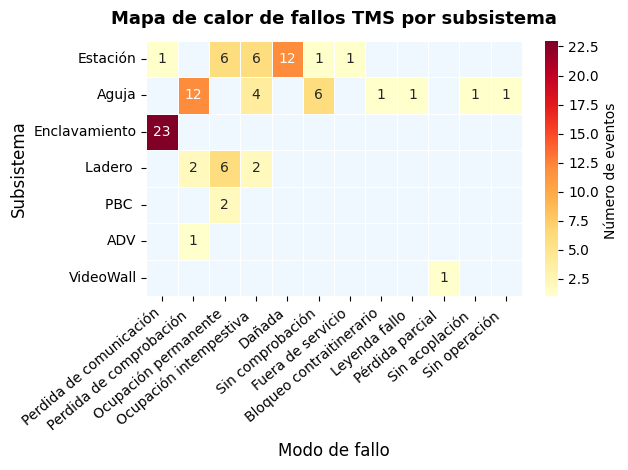

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear máscara para ocultar los ceros
mask = tabla == 0

# Crear una copia del mapa de colores
cmap = sns.color_palette("YlOrRd", as_cmap=True)

# Color para los valores enmascarados (ceros)
cmap.set_bad(color="aliceblue")


sns.heatmap(
    tabla,
    mask=mask,
    annot=tabla,
    fmt="d",
    cmap=cmap,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Número de eventos "}
)

plt.title(
    "Mapa de calor de fallos TMS por subsistema",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xticks(rotation=40, ha="right")
plt.yticks(rotation=0)

plt.xlabel("Modo de fallo", fontsize=12)
plt.ylabel("Subsistema", fontsize=12)

plt.tight_layout()
plt.show()


Text(50.72222222222221, 0.5, 'Subsistema')

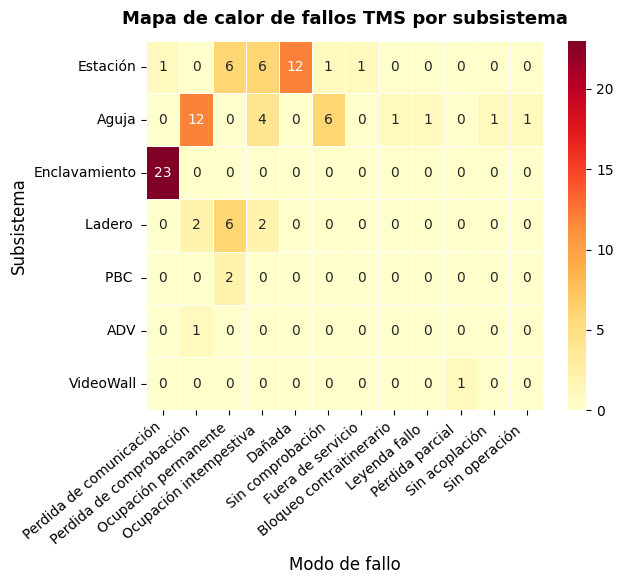

In [ ]:
# Crear mapa de calor
sns.heatmap(
    tabla,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    linewidths=0.5
)

#titulo
plt.title(
    "Mapa de calor de fallos TMS por subsistema",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.xticks(rotation=40, ha="right")
plt.yticks(rotation=0)

plt.xlabel("Modo de fallo", fontsize=12)
plt.ylabel("Subsistema", fontsize=12)

# **3. Análisis del subsistema:ENCLAVAMIENTO**

## a. Índice de recurrencia por equipo (ENCLAVAMIENTO)


In [ ]:
top_equipos = (
    df[df["Subsistema"] == "Enclavamiento"]
    .groupby("Equipo afectado")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

print(top_equipos)

Equipo afectado
IXL5 e IXL6    12
IXL6            4
IXL5            3
IXL5 e IXL7     1
IXL5 e IXL8     1
TODOS           1
dtype: int64


## b . Tiempo acumulado de indisponibilidad

In [ ]:
indisponibilidad = (
    df[df["Subsistema"] == "Enclavamiento"]
    .groupby("Equipo afectado")["Duración (min)"]
    .sum()
    .sort_values(ascending=False)
)

print(indisponibilidad.head(10))

Equipo afectado
IXL6                                            XXXXXXXXXXXX0:01
IXL5                                                XXXX0:028:26
IXL5 e IXL7                                                 XXXX
IXL5 e IXL8                                                 XXXX
TODOS                                                       XXXX
IXL5 e IXL6    4:31:00 p.m.2:24:00 a.m.XXXX5:58:002:51:00 a.m...
Name: Duración (min), dtype: object


Primero se limpia las horas concatenadas.

In [ ]:
print(df["Duración (min)"].sample(20))

13    XXXX
15    XXXX
57    1:51
49    XXXX
75    XXXX
86    XXXX
44    XXXX
2     XXXX
10    4:05
25    XXXX
36    XXXX
79    0:01
33    XXXX
65    XXXX
84    XXXX
4     XXXX
85    XXXX
81    XXXX
45    XXXX
35    0:02
Name: Duración (min), dtype: object


In [ ]:
#Convertir la columna a texto
df["Duración (min)"] = df["Duración (min)"].astype(str)

In [ ]:
#Remplazar los valores invalidos
df["Duración (min)"] = df["Duración (min)"].replace(
    ["XXXX", "nan", "None", ""],
    pd.NA
)

In [ ]:
#Extraer únicamente la primera duración válida
import re

def extraer_duracion(valor):

    if pd.isna(valor):
        return pd.NA

    patron = re.search(r"\d{1,2}:\d{2}(?::\d{2})?", str(valor))

    if patron:
        return patron.group(0)

    return pd.NA

df["duracion_limpia"] = df["Duración (min)"].apply(extraer_duracion)

In [ ]:
#Convertir a minutos
def a_minutos(valor):

    if pd.isna(valor):
        return pd.NA

    partes = valor.split(":")

    if len(partes) == 2:
        horas, minutos = map(int, partes)
        return horas * 60 + minutos

    elif len(partes) == 3:
        horas, minutos, segundos = map(int, partes)
        return horas * 60 + minutos + segundos / 60

    return pd.NA

df["duracion_min"] = df["duracion_limpia"].apply(a_minutos)

In [ ]:
#Validar resultados
print(
    df[
        ["Equipo afectado", "Duración (min)", "duracion_limpia", "duracion_min"]
    ].head(20)
)

   Equipo afectado Duración (min) duracion_limpia duracion_min
0      IXL5 e IXL6   4:31:00 p.m.         4:31:00        271.0
1      IXL5 e IXL6   2:24:00 a.m.         2:24:00        144.0
2             IXL6           <NA>            <NA>         <NA>
3             IXL6           <NA>            <NA>         <NA>
4             IXL5           <NA>            <NA>         <NA>
5             IXL6           <NA>            <NA>         <NA>
6      IXL5 e IXL6           <NA>            <NA>         <NA>
7      IXL5 e IXL6        5:58:00         5:58:00        358.0
8      IXL5 e IXL6   2:51:00 a.m.         2:51:00        171.0
9     Aguja A5 TIX     Sin cerrar            <NA>         <NA>
10      A14 y A17            4:05            4:05          245
11             NaN           4:09            4:09          249
12          MET A9           <NA>            <NA>         <NA>
13         IZA A11           <NA>            <NA>         <NA>
14             TIX           <NA>            <NA>      

Tiempo indisponible por hs, min y dias

In [ ]:
# Filtrar solo Enclavamiento
df_encl = df[df["Subsistema"] == "Enclavamiento"].copy()

# Calcular tiempo acumulado en minutos
tiempo_total_min = df_encl["duracion_min"].sum()

# Conversiones
tiempo_total_horas = tiempo_total_min / 60
tiempo_total_dias = tiempo_total_min / 1440

# Mostrar resultados
print(f"Tiempo acumulado de indisponibilidad: {tiempo_total_min:.0f} minutos")
print(f"Tiempo acumulado de indisponibilidad: {tiempo_total_horas:.2f} horas")
print(f"Tiempo acumulado de indisponibilidad en enclavamiento: {tiempo_total_dias:.2f} días")

Tiempo acumulado de indisponibilidad: 2432 minutos
Tiempo acumulado de indisponibilidad: 40.53 horas
Tiempo acumulado de indisponibilidad en enclavamiento: 1.69 días


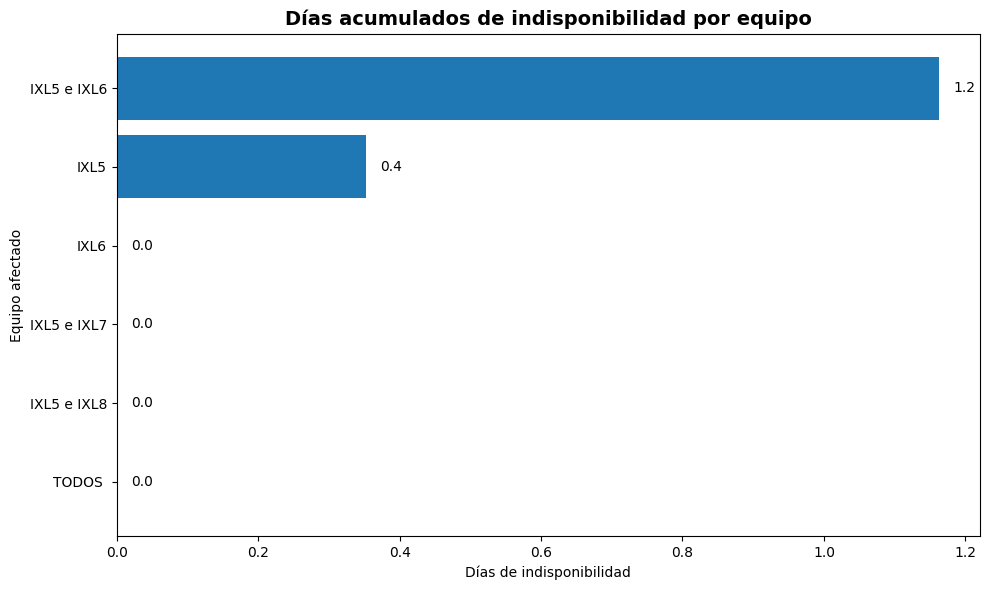

In [ ]:
import matplotlib.pyplot as plt

# Filtrar enclavamientos
df_encl = df[df["Subsistema"].str.strip() == "Enclavamiento"].copy()

# Calcular días de impacto por equipo
impacto = (
    df_encl
    .groupby("Equipo afectado")["duracion_min"]
    .sum()
    .div(1440)  # Convertir minutos a días
    .sort_values(ascending=False)
)

# Mostrar los 10 equipos con mayor impacto
top10 = impacto.head(10)

plt.figure(figsize=(10, 6))

plt.barh(top10.index, top10.values)

plt.gca().invert_yaxis()

plt.title(
    "Días acumulados de indisponibilidad por equipo",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Días de indisponibilidad")
plt.ylabel("Equipo afectado")

# Etiquetas sobre las barras
for i, valor in enumerate(top10.values):
    plt.text(valor + 0.02, i, f"{valor:.1f}", va="center")

plt.tight_layout()
plt.show()

AttributeError: Can only use .dt accessor with datetimelike values

In [ ]:
pip install calplot

In [ ]:
import pandas as pd
import calplot
import matplotlib.pyplot as plt

# Asegurar formato fecha
df["Fecha"] = pd.to_datetime(df["Fecha"])

# Filtrar solo enclavamientos
df_encl = df[df["Subsistema"].str.strip() == "Enclavamiento"].copy()

# Contar número de fallos por día
fallos_dia = (
    df_encl
    .groupby("Fecha")
    .size()
)

plt.figure(figsize=(14, 4))

calplot.calplot(
    fallos_dia,
    cmap="Reds",
    colorbar=True,
    suptitle="Calendario de fallos de enclavamientos - 2026"
)

plt.show()

In [ ]:
impacto_dia = (
    df_encl
    .groupby("Fecha")["duracion_min"]
    .sum()
)

calplot.calplot(
    impacto_dia,
    cmap="Reds",
    colorbar=True,
    suptitle="Calendario de indisponibilidad de enclavamientos"
)

plt.show()

In [ ]:

import calendar
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Días con al menos un fallo
fallos_dia = (
    df_junio
    .groupby(df_junio["Fecha"].dt.day)
    .size()
    .clip(upper=1)
)

# Crear matriz del calendario
cal = calendar.monthcalendar(2026, 6)
matriz = np.array(cal)

# Reemplazar días sin mes por NaN
matriz = np.where(matriz == 0, np.nan, matriz)

# Marcar días con fallos
heatmap = np.zeros_like(matriz, dtype=float)

for i in range(matriz.shape[0]):
    for j in range(matriz.shape[1]):
        dia = matriz[i, j]
        if not np.isnan(dia):
            heatmap[i, j] = fallos_dia.get(int(dia), 0)

plt.figure(figsize=(10, 4))

sns.heatmap(
    heatmap,
    annot=matriz,
    fmt=".0f",
    cmap="Reds",
    cbar=False,
    linewidths=1,
    linecolor="white"
)

plt.title("Calendario de fallos de enclavamientos - Junio 2026")

plt.xticks(
    np.arange(7) + 0.5,
    ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
)

plt.yticks([])

plt.show()

In [ ]:
import pandas as pd
import numpy as np
import calendar
import seaborn as sns
import matplotlib.pyplot as plt

# Asegurar formato fecha
df["Fecha"] = pd.to_datetime(df["Fecha"]).dt.normalize()

# Normalizar el nombre del subsistema
df["Subsistema"] = (
    df["Subsistema"]
    .astype(str)
    .str.strip()
    .str.title()
)

# Filtrar fallos de enclavamiento de julio de 2026
df_julio = df[
    (df["Subsistema"] == "Enclavamiento") &
    (df["Fecha"].dt.year == 2026) &
    (df["Fecha"].dt.month == 6)
].copy()

# Contar fallos por día
fallos_dia = (
    df_julio
    .groupby(df_julio["Fecha"].dt.day)
    .size()
)

# Crear estructura del calendario
cal = calendar.monthcalendar(2026, 7)

# Matrices para el mapa de calor y las anotaciones
heatmap = np.full((len(cal), 7), np.nan)
annot = np.full((len(cal), 7), "", dtype=object)

for semana_idx, semana in enumerate(cal):
    for dia_idx, dia in enumerate(semana):

        if dia != 0:
            n_fallos = fallos_dia.get(dia, 0)

            heatmap[semana_idx, dia_idx] = n_fallos
            annot[semana_idx, dia_idx] = f"{dia}\n({n_fallos})"

# Configurar color
cmap = sns.color_palette("Reds", as_cmap=True)
cmap.set_under("lightgray")

plt.figure(figsize=(12, 5))

sns.heatmap(
    heatmap,
    annot=annot,
    fmt="",
    cmap=cmap,
    vmin=0.1,
    linewidths=1,
    linecolor="white",
    cbar_kws={"label": "Número de fallos"}
)

plt.title(
    "Calendario de fallos de enclavamientos - Julio 2026",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.xticks(
    np.arange(7) + 0.5,
    ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
)

plt.yticks([])

plt.tight_layout()
plt.show()

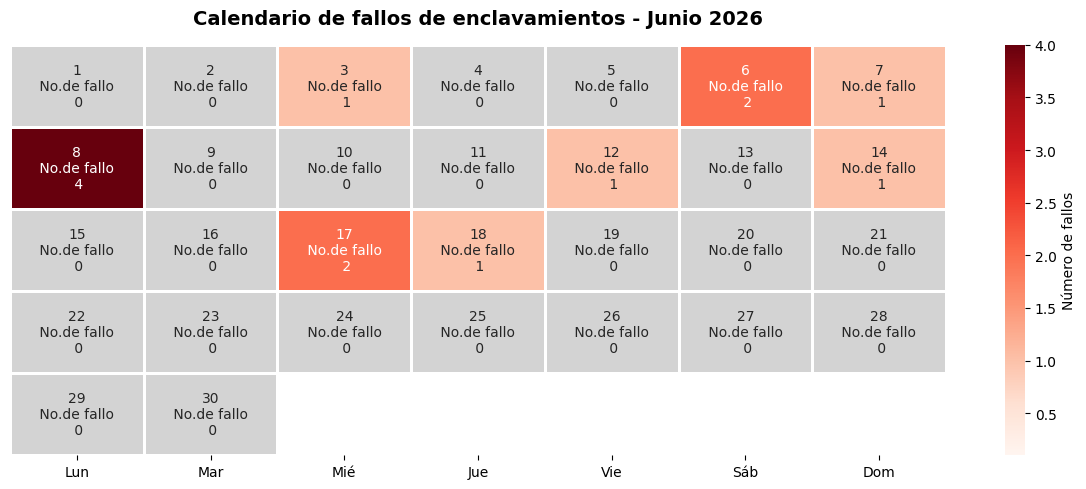

In [ ]:
import pandas as pd
import numpy as np
import calendar
import seaborn as sns
import matplotlib.pyplot as plt

# Parámetros
anio = 2026
mes = 6

# Asegurar formato de fecha
df["Fecha"] = pd.to_datetime(df["Fecha"]).dt.normalize()

# Normalizar el nombre del subsistema
df["Subsistema"] = (
    df["Subsistema"]
    .astype(str)
    .str.strip()
    .str.title()
)

# Filtrar fallos de enclavamiento del mes seleccionado
df_mes = df[
    (df["Subsistema"] == "Enclavamiento") &
    (df["Fecha"].dt.year == anio) &
    (df["Fecha"].dt.month == mes)
].copy()

# Contar fallos por día
fallos_dia = (
    df_mes
    .groupby(df_mes["Fecha"].dt.day)
    .size()
)

# Crear calendario del mes
cal = calendar.monthcalendar(anio, mes)

# Crear matrices
heatmap = np.full((len(cal), 7), np.nan)
annot = np.full((len(cal), 7), "", dtype=object)

for semana_idx, semana in enumerate(cal):
    for dia_idx, dia in enumerate(semana):

        if dia != 0:
            n_fallos = fallos_dia.get(dia, 0)

            heatmap[semana_idx, dia_idx] = n_fallos
            annot[semana_idx, dia_idx] = f"{dia}\n No.de fallo \n {n_fallos}"

# Configurar colores
cmap = sns.color_palette("Reds", as_cmap=True)
cmap.set_under("lightgray")

plt.figure(figsize=(12, 5))

sns.heatmap(
    heatmap,
    annot=annot,
    fmt="",
    cmap=cmap,
    vmin=0.1,
    linewidths=1,
    linecolor="white",
    cbar_kws={"label": "Número de fallos"}
)

nombre_mes = calendar.month_name[mes]

plt.title(
    f"Calendario de fallos de enclavamientos - Junio {anio}",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.xticks(
    np.arange(7) + 0.5,
    ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
)

plt.yticks([])

plt.tight_layout()
plt.show()